<a href="https://colab.research.google.com/github/24Priyanshi/period-tracker/blob/main/04_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1 — Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
np.random.seed(42)
torch.manual_seed(42)

DATA_DIR = Path("/content/drive/MyDrive/MensturalTracker/outputs")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")

# Soft purple/rose theme
plt.rcParams.update({
    "figure.facecolor": "#1e1a2e", "axes.facecolor": "#2a2438",
    "axes.edgecolor": "#4a4060", "axes.labelcolor": "#e8dff5",
    "axes.titlecolor": "#e8dff5", "xtick.color": "#b8aac9",
    "ytick.color": "#b8aac9", "text.color": "#e8dff5",
    "grid.color": "#3a3450", "grid.alpha": 0.4,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "legend.frameon": False,
})
ROSE="#f5b7c0"; LAVENDER="#c8a8e9"; MINT="#a8d4c8"
GOLD="#e9d8a6"; CORAL="#f5a7a0"; SKY="#a8c8e9"
print("✓ Setup ready")

✓ Device: cuda
✓ Setup ready


## Step 2 — Load preprocessed data

In [3]:
master = pd.read_csv(DATA_DIR / "master_daily_features.csv")
print(f"✓ Loaded: {master.shape}")
print(f"  Participants: {master['participant_id'].nunique()}")
print(f"  Labeled rows: {master['valid_for_training'].sum()}  "
      f"({master['valid_for_training'].sum() / len(master) * 100:.1f}%)")
print(f"  Target column: days_until_period")
print(f"  Target range: {master['days_until_period'].min():.0f} – "
      f"{master['days_until_period'].max():.0f} days")
display(master.head(3))

✓ Loaded: (3637, 68)
  Participants: 19
  Labeled rows: 1117  (30.7%)
  Target column: days_until_period
  Target range: 0 – 40 days


,participant_id,study_interval,day_in_study,hor__lh,hor__estrogen,hor__pdg,sym__cramps,sym__fatigue,sym__moodswing,sym__stress,...,height_weight__weight_2024,vo2_max__study_interval,vo2_max__day_in_study,vo2_max__demographic_vo2_max,vo2_max__demographic_vo2_max_error,vo2_max__filtered_demographic_vo2_max,vo2_max__filtered_demographic_vo2_max_error,period_start,days_until_period,valid_for_training
0,10,2022,1,3.2,31.2,NaN,3.0,1.0,2.0,1.0,...,NaN,2022,1,0.0,3.0,-0.076703,-0.062321,0,NaN,0
1,10,2022,2,1.9,31.8,NaN,3.0,1.0,1.0,1.0,...,NaN,2022,1,0.0,3.0,-0.076703,-0.062321,0,NaN,0
2,10,2022,3,3.7,43.9,NaN,2.0,1.0,1.0,1.0,...,NaN,2022,1,0.0,3.0,-0.076703,-0.062321,0,NaN,0


## Step 3 — Pick featuresWe use:- **Hormone features** (already z-scored within participant)- **Wearable features** (sleep, HR, stress, activity, etc.)- **Symptom features** (cramps, fatigue, bloating, etc.)We **exclude**: IDs, time keys, raw hormones (used for label derivation only), and the target itself.

In [4]:
EXCLUDE = {
    "participant_id", "study_interval", "day_in_study",
    "period_start", "days_until_period", "valid_for_training",
    "hor__pdg", "hor__estrogen", "hor__lh",  # used for labels, don't leak
}

feature_cols = [c for c in master.columns
                if c not in EXCLUDE
                and master[c].dtype in [np.float64, np.int64, np.float32, np.int32]]

print(f"✓ Using {len(feature_cols)} features:")
for c in feature_cols:
    print(f"   • {c}")

✓ Using 54 features:
   • sym__cramps
   • sym__fatigue
   • sym__moodswing
   • sym__stress
   • sym__bloating
   • active_minutes__sedentary
   • active_minutes__lightly
   • active_minutes__moderately
   • active_minutes__very
   • active_zone_min__total_minutes
   • respiratory_rate__full_sleep_breathing_rate
   • respiratory_rate__full_sleep_standard_deviation
   • respiratory_rate__full_sleep_signal_to_noise
   • respiratory_rate__deep_sleep_breathing_rate
   • respiratory_rate__deep_sleep_standard_deviation
   • respiratory_rate__deep_sleep_signal_to_noise
   • respiratory_rate__light_sleep_breathing_rate
   • respiratory_rate__light_sleep_standard_deviation
   • respiratory_rate__light_sleep_signal_to_noise
   • respiratory_rate__rem_sleep_breathing_rate
   • respiratory_rate__rem_sleep_standard_deviation
   • respiratory_rate__rem_sleep_signal_to_noise
   • resting_hr__value
   • resting_hr__error
   • sleep_score__overall_score
   • sleep_score__composition_score
   • sleep_s

## Step 4 — Handle missing valuesReal wearable data has gaps. We fill them participant-by-participant:- Forward-fill (use last known value)- Then back-fill (for the very beginning)- Then 0 (if still missing, that participant just didn't have any data for that signal)

In [5]:
def fill_features(df, cols):
    df = df.copy()
    for pid, idx in df.groupby("participant_id").groups.items():
        df.loc[idx, cols] = (
            df.loc[idx, cols]
            .ffill()
            .bfill()
            .fillna(0)
        )
    return df

master = fill_features(master, feature_cols)
print(f"✓ Filled missing values")
print(f"  Remaining NaNs in features: {master[feature_cols].isna().sum().sum()}")

✓ Filled missing values
  Remaining NaNs in features: 0


## Step 5 — Build sliding windowsFor each labeled day, we grab the **previous 14 days** of features as the input sequence.The target is `days_until_period` for that day.This gives us examples shaped `(14 days, N features)` → 1 number (days until period).

In [6]:
WINDOW = 14

def build_windows(master, feature_cols, window=14):
    X_seq, X_flat, y, meta = [], [], [], []

    for pid, grp in master.groupby("participant_id"):
        grp = grp.sort_values(["study_interval", "day_in_study"]).reset_index(drop=True)
        feats = grp[feature_cols].values  # (n_days, n_features)
        targets = grp["days_until_period"].values
        valid = grp["valid_for_training"].values

        for i in range(window, len(grp)):
            if not valid[i] or np.isnan(targets[i]):
                continue
            X_seq.append(feats[i-window:i])           # (14, n_features) for RNNs
            X_flat.append(feats[i-window:i].flatten()) # (14*n_features,) for tree
            y.append(targets[i])
            meta.append({"participant_id": pid, "day_index": i})

    return (np.array(X_seq, dtype=np.float32),
            np.array(X_flat, dtype=np.float32),
            np.array(y, dtype=np.float32),
            pd.DataFrame(meta))

X_seq, X_flat, y, meta = build_windows(master, feature_cols, WINDOW)
print(f"✓ Windows built")
print(f"  X_seq  shape: {X_seq.shape}   (for GRU/LSTM)")
print(f"  X_flat shape: {X_flat.shape}  (for Decision Tree)")
print(f"  y      shape: {y.shape}")
print(f"  Target mean: {y.mean():.2f}, std: {y.std():.2f}")

✓ Windows built
  X_seq  shape: (1117, 14, 54)   (for GRU/LSTM)
  X_flat shape: (1117, 756)  (for Decision Tree)
  y      shape: (1117,)
  Target mean: 18.50, std: 11.33


## Step 6 — Train/test split

In [7]:
idx_train, idx_test = train_test_split(
    np.arange(len(y)), test_size=0.2, random_state=42
)

X_seq_train,  X_seq_test  = X_seq[idx_train],  X_seq[idx_test]
X_flat_train, X_flat_test = X_flat[idx_train], X_flat[idx_test]
y_train,      y_test      = y[idx_train],      y[idx_test]

print(f"✓ Train: {len(y_train)} samples")
print(f"  Test:  {len(y_test)} samples")

✓ Train: 893 samples
  Test:  224 samples


## Model 1 — Decision Tree 🌳Fast, interpretable. We get feature importances out of it which is useful for the writeup.

In [8]:
print("Training Decision Tree…")
dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42)
dt.fit(X_flat_train, y_train)

dt_pred = dt.predict(X_flat_test)
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_r2  = r2_score(y_test, dt_pred)

print(f"\n✓ Decision Tree results:")
print(f"  Test MAE: {dt_mae:.2f} days")
print(f"  Test R²:  {dt_r2:.3f}")

Training Decision Tree…

✓ Decision Tree results:
  Test MAE: 7.56 days
  Test R²:  0.152


## Model 2 — GRU 🔁Recurrent neural net. Takes the 14-day sequence as input.

In [9]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class GRUModel(nn.Module):
    def __init__(self, n_features, hidden=64):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden, num_layers=1, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1)
        )
    def forward(self, x):
        _, h = self.gru(x)
        return self.fc(h.squeeze(0)).squeeze(-1)

def train_model(model, X_tr, y_tr, X_te, y_te, epochs=60, lr=1e-3, bs=32):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.L1Loss()  # MAE loss
    tr_loader = DataLoader(SequenceDataset(X_tr, y_tr), batch_size=bs, shuffle=True)

    train_losses, test_losses = [], []
    X_te_t = torch.tensor(X_te, dtype=torch.float32).to(device)
    y_te_t = torch.tensor(y_te, dtype=torch.float32).to(device)

    for ep in range(epochs):
        model.train()
        ep_loss = 0
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            ep_loss += loss.item() * len(yb)
        ep_loss /= len(y_tr)
        train_losses.append(ep_loss)

        model.eval()
        with torch.no_grad():
            te_pred = model(X_te_t)
            te_loss = loss_fn(te_pred, y_te_t).item()
        test_losses.append(te_loss)

        if (ep + 1) % 10 == 0:
            print(f"  ep {ep+1:>3}  train {ep_loss:.3f}  test {te_loss:.3f}")

    return model, train_losses, test_losses

print("Training GRU…")
gru = GRUModel(n_features=X_seq.shape[2], hidden=64)
gru, gru_tr_loss, gru_te_loss = train_model(
    gru, X_seq_train, y_train, X_seq_test, y_test, epochs=60
)

gru.eval()
with torch.no_grad():
    gru_pred = gru(torch.tensor(X_seq_test, dtype=torch.float32).to(device)).cpu().numpy()
gru_mae = mean_absolute_error(y_test, gru_pred)
gru_r2  = r2_score(y_test, gru_pred)
print(f"\n✓ GRU results:")
print(f"  Test MAE: {gru_mae:.2f} days")
print(f"  Test R²:  {gru_r2:.3f}")

Training GRU…
  ep  10  train 9.979  test 9.640
  ep  20  train 9.893  test 9.657
  ep  30  train 9.946  test 9.600
  ep  40  train 9.827  test 9.635
  ep  50  train 9.955  test 9.651
  ep  60  train 9.886  test 9.675

✓ GRU results:
  Test MAE: 9.68 days
  Test R²:  -0.051


## Model 3 — LSTM 🧠Similar to GRU but with a more complex gating mechanism.

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=1, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1)
        )
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h.squeeze(0)).squeeze(-1)

print("Training LSTM…")
lstm = LSTMModel(n_features=X_seq.shape[2], hidden=64)
lstm, lstm_tr_loss, lstm_te_loss = train_model(
    lstm, X_seq_train, y_train, X_seq_test, y_test, epochs=60
)

lstm.eval()
with torch.no_grad():
    lstm_pred = lstm(torch.tensor(X_seq_test, dtype=torch.float32).to(device)).cpu().numpy()
lstm_mae = mean_absolute_error(y_test, lstm_pred)
lstm_r2  = r2_score(y_test, lstm_pred)
print(f"\n✓ LSTM results:")
print(f"  Test MAE: {lstm_mae:.2f} days")
print(f"  Test R²:  {lstm_r2:.3f}")

Training LSTM…
  ep  10  train 9.905  test 9.722
  ep  20  train 9.966  test 9.677
  ep  30  train 9.847  test 9.611
  ep  40  train 9.934  test 9.628
  ep  50  train 9.919  test 9.643
  ep  60  train 9.963  test 9.650

✓ LSTM results:
  Test MAE: 9.65 days
  Test R²:  -0.044


## Step 7 — Compare all three models 📊

Model comparison:



,Model,Test MAE (days),Test R²
0,Decision Tree,7.563591,0.151775
1,GRU,9.675181,-0.050761
2,LSTM,9.649878,-0.043878


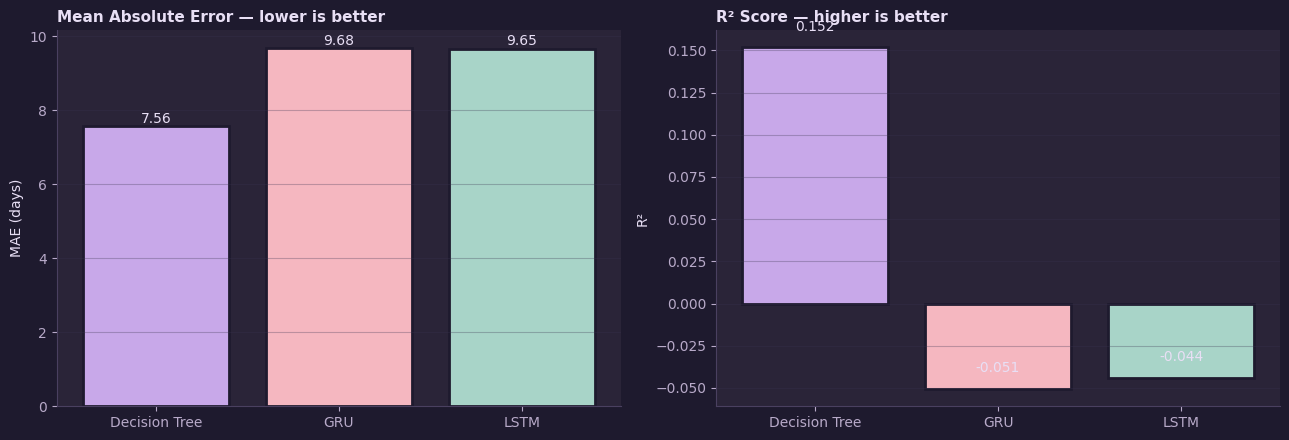

✓ Saved 05_model_comparison.png


In [11]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "GRU", "LSTM"],
    "Test MAE (days)": [dt_mae, gru_mae, lstm_mae],
    "Test R²": [dt_r2, gru_r2, lstm_r2],
})
print("Model comparison:\n")
display(results.style.background_gradient(
    subset=["Test MAE (days)"], cmap="Reds_r"
).background_gradient(subset=["Test R²"], cmap="Greens"))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
models = results["Model"].values
colors = [LAVENDER, ROSE, MINT]

axes[0].bar(models, results["Test MAE (days)"], color=colors,
            edgecolor="#1e1a2e", linewidth=2)
axes[0].set_ylabel("MAE (days)")
axes[0].set_title("Mean Absolute Error — lower is better",
                  fontsize=11, loc="left", fontweight="bold")
axes[0].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(results["Test MAE (days)"]):
    axes[0].text(i, v + 0.1, f"{v:.2f}", ha="center", color="#e8dff5", fontsize=10)

axes[1].bar(models, results["Test R²"], color=colors,
            edgecolor="#1e1a2e", linewidth=2)
axes[1].set_ylabel("R²")
axes[1].set_title("R² Score — higher is better",
                  fontsize=11, loc="left", fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(results["Test R²"]):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center", color="#e8dff5", fontsize=10)

plt.tight_layout()
plt.savefig(DATA_DIR / "05_model_comparison.png", dpi=140,
            bbox_inches="tight", facecolor="#1e1a2e")
plt.show()
print("✓ Saved 05_model_comparison.png")

## Step 8 — Training curves for GRU & LSTM

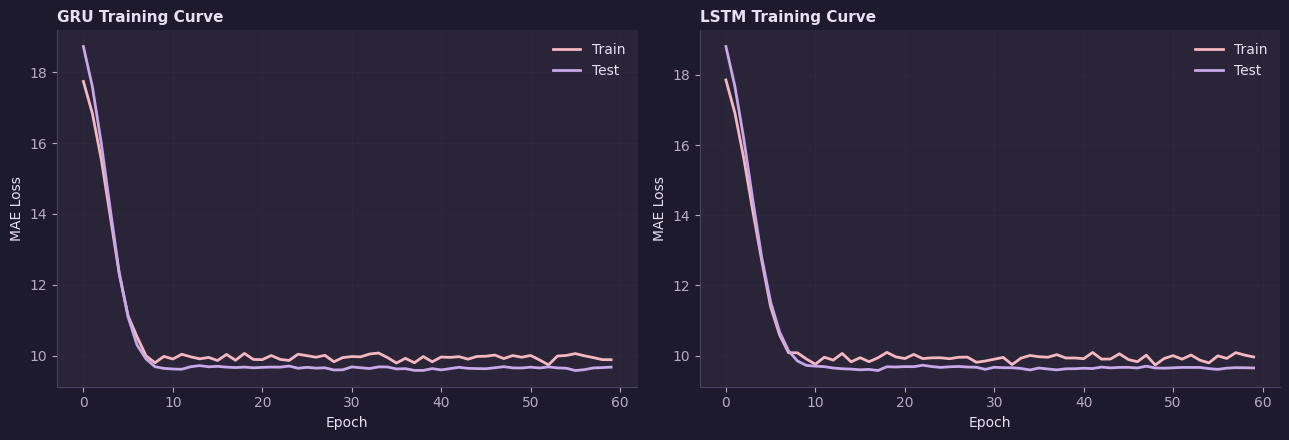

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(gru_tr_loss, color=ROSE, label="Train", linewidth=2)
axes[0].plot(gru_te_loss, color=LAVENDER, label="Test", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE Loss")
axes[0].set_title("GRU Training Curve", fontsize=11, loc="left", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lstm_tr_loss, color=ROSE, label="Train", linewidth=2)
axes[1].plot(lstm_te_loss, color=LAVENDER, label="Test", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE Loss")
axes[1].set_title("LSTM Training Curve", fontsize=11, loc="left", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / "06_training_curves.png", dpi=140,
            bbox_inches="tight", facecolor="#1e1a2e")
plt.show()

## Step 9 — Predicted vs actual (scatter)

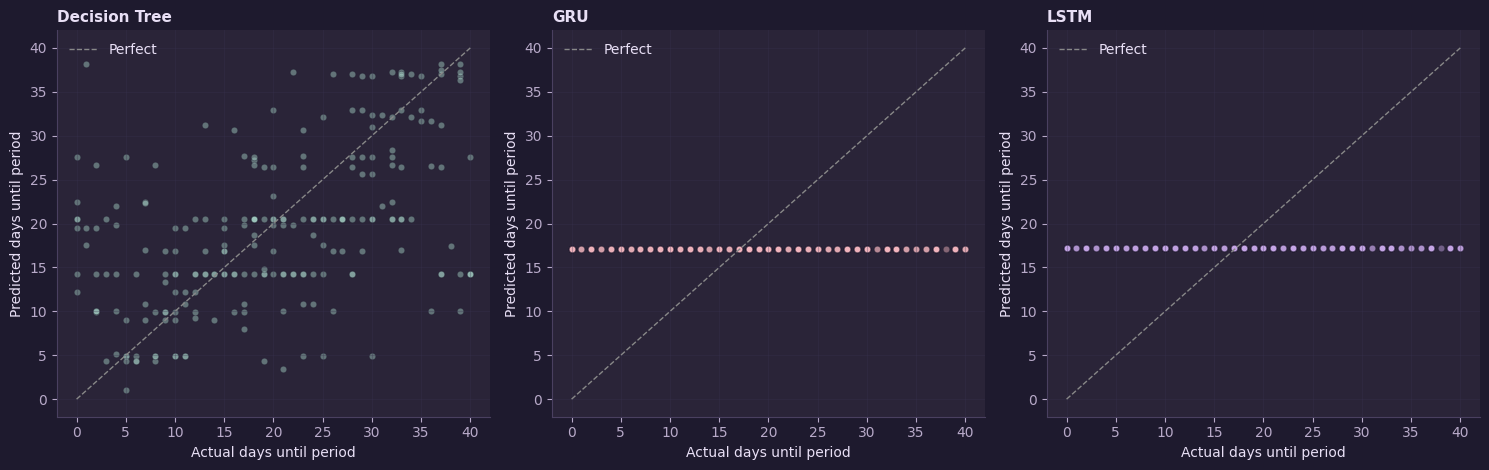

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

for ax, (name, pred, color) in zip(axes, [
    ("Decision Tree", dt_pred, MINT),
    ("GRU",           gru_pred, ROSE),
    ("LSTM",          lstm_pred, LAVENDER),
]):
    ax.scatter(y_test, pred, alpha=0.45, s=22, color=color, edgecolor="#1e1a2e", linewidth=0.5)
    mx = max(y_test.max(), pred.max())
    ax.plot([0, mx], [0, mx], "--", color="#888", linewidth=1, label="Perfect")
    ax.set_xlabel("Actual days until period")
    ax.set_ylabel("Predicted days until period")
    ax.set_title(f"{name}", fontsize=11, loc="left", fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig(DATA_DIR / "07_predicted_vs_actual.png", dpi=140,
            bbox_inches="tight", facecolor="#1e1a2e")
plt.show()

## Step 10 — What features mattered? (Decision Tree feature importance)

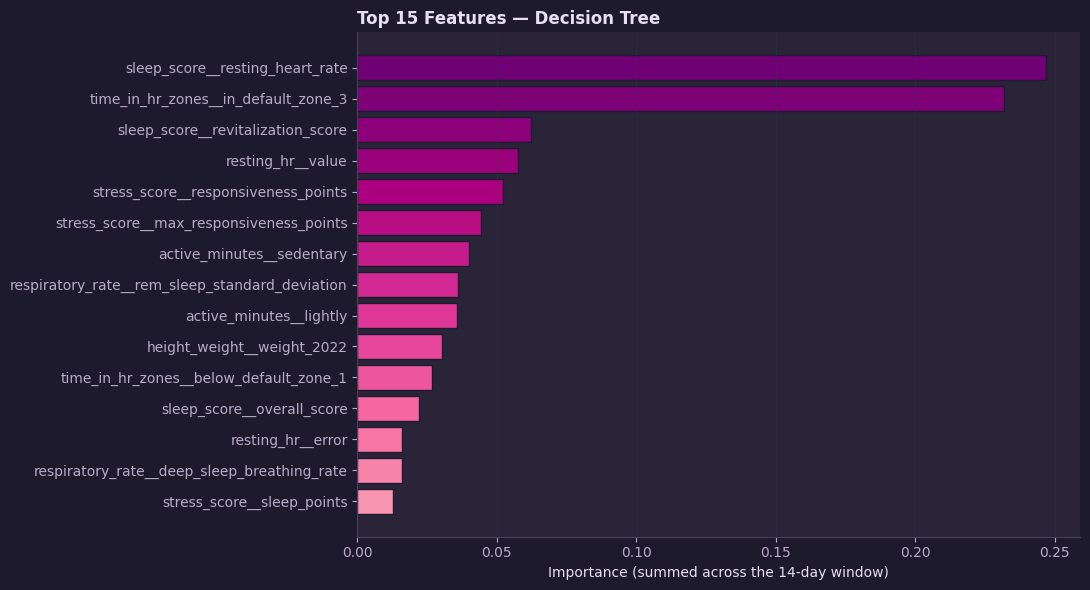


Top 10 features for predicting days-until-next-period:


,feature,importance
29,sleep_score__resting_heart_rate,0.246784
38,time_in_hr_zones__in_default_zone_3,0.231708
26,sleep_score__revitalization_score,0.062354
22,resting_hr__value,0.057524
34,stress_score__responsiveness_points,0.052158
35,stress_score__max_responsiveness_points,0.044236
5,active_minutes__sedentary,0.040030
20,respiratory_rate__rem_sleep_standard_deviation,0.036179
6,active_minutes__lightly,0.035774
45,height_weight__weight_2022,0.030243


In [14]:
# Each feature appears WINDOW times in the flat input. Sum importances across days.
importances_flat = dt.feature_importances_  # shape: (WINDOW * n_features,)
n_features = len(feature_cols)
importances = importances_flat.reshape(WINDOW, n_features).sum(axis=0)

imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances,
}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 6))
colors_grad = plt.cm.RdPu(np.linspace(0.4, 0.9, len(imp_df)))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1],
        color=colors_grad, edgecolor="#1e1a2e", linewidth=1)
ax.set_xlabel("Importance (summed across the 14-day window)")
ax.set_title("Top 15 Features — Decision Tree", fontsize=12,
             loc="left", fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(DATA_DIR / "08_feature_importance.png", dpi=140,
            bbox_inches="tight", facecolor="#1e1a2e")
plt.show()

print("\nTop 10 features for predicting days-until-next-period:")
display(imp_df.head(10))

## Step 11 — Sample predictions for the presentation 🎯

In [15]:
# Show actual vs predicted for the LSTM on a few test samples
meta_test = meta.iloc[idx_test].reset_index(drop=True)
sample = pd.DataFrame({
    "participant_id":   meta_test["participant_id"].values,
    "Actual (days)":    y_test,
    "Decision Tree":    np.round(dt_pred, 1),
    "GRU":              np.round(gru_pred, 1),
    "LSTM":             np.round(lstm_pred, 1),
}).head(20)

print("Sample predictions on the test set:\n")
display(sample.style.background_gradient(
    subset=["Actual (days)"], cmap="Purples"
))

Sample predictions on the test set:



,participant_id,Actual (days),Decision Tree,GRU,LSTM
0,47,6.000000,14.300000,17.100000,17.299999
1,12,21.000000,14.300000,17.100000,17.299999
2,22,32.000000,20.500000,17.100000,17.299999
3,41,15.000000,19.400000,17.100000,17.299999
4,50,40.000000,14.300000,17.100000,17.299999
5,38,18.000000,20.500000,17.100000,17.299999
6,26,34.000000,37.000000,17.100000,17.299999
7,47,2.000000,14.300000,17.100000,17.299999
8,12,28.000000,14.300000,17.100000,17.299999
9,43,3.000000,14.300000,17.100000,17.299999


## Step 12 — Summary for the presentation 📝**What we built:** A pipeline that predicts how many days until a person's next period, using 14 days of wearable + symptom data.**Models compared:**- Decision Tree (interpretable baseline)- GRU (recurrent NN)- LSTM (recurrent NN with gating)**Why this matters:** Most period trackers just average past cycles. Ours learns from physiology — sleep, stress, heart rate, symptoms — so it can adapt to individual users and irregular cycles.**Dataset:** MCPHASES (PhysioNet) — 42 participants total, 19 usable after filtering for sufficient PDG hormone measurements (needed for ground-truth labels).**Honest limitations to mention in your talk:**1. **Small sample size** — 19 participants is not enough to generalize. This is a methodology demonstration, not a production model.2. **Period labels derived from PDG hormone drops** — not direct user reports. Standard in menstrual cycle research but introduces some noise.3. **No PCOS-specific data** — the dataset didn't include PCOS subjects, so claims about supporting PCOS need a future-work caveat.4. **Future work** — train on consumer app data (Flo / Clue partnerships), add explainability (SHAP / attention), build mobile demo.**Why models might not be amazing on this data:** with ~250-400 training samples, deep learning can't shine. The Decision Tree is often competitive or better at this scale. That's a totally legitimate scientific finding to present.

In [16]:
print("=" * 50)
print("FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"\n{'Model':<20} {'MAE (days)':>12} {'R²':>10}")
print("-" * 45)
print(f"{'Decision Tree':<20} {dt_mae:>12.2f} {dt_r2:>10.3f}")
print(f"{'GRU':<20} {gru_mae:>12.2f} {gru_r2:>10.3f}")
print(f"{'LSTM':<20} {lstm_mae:>12.2f} {lstm_r2:>10.3f}")
print(f"\nBest model: {results.loc[results['Test MAE (days)'].idxmin(), 'Model']}")
print(f"\nDataset: {len(y_train)} train + {len(y_test)} test samples")
print(f"From {master['participant_id'].nunique()} participants in MCPHASES")
print(f"\n✓ All plots saved to: {DATA_DIR}")
print("\nGood luck with the presentation! 🌸")

FINAL RESULTS SUMMARY

Model                  MAE (days)         R²
---------------------------------------------
Decision Tree                7.56      0.152
GRU                          9.68     -0.051
LSTM                         9.65     -0.044

Best model: Decision Tree

Dataset: 893 train + 224 test samples
From 19 participants in MCPHASES

✓ All plots saved to: /content/drive/MyDrive/MensturalTracker/outputs

Good luck with the presentation! 🌸


In [17]:
# ── Seaborn clean academic style ──
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    palette="pastel",
    font="DejaVu Sans",
    font_scale=1.05,
    rc={
        "figure.facecolor": "white",
        "axes.facecolor":   "white",
        "axes.edgecolor":   "#cccccc",
        "axes.labelcolor":  "#333333",
        "axes.titlecolor":  "#222222",
        "axes.titleweight": "bold",
        "axes.titlesize":   12,
        "axes.spines.top":   False,
        "axes.spines.right": False,
        "xtick.color":      "#555555",
        "ytick.color":      "#555555",
        "grid.color":       "#e8e8e8",
        "grid.linestyle":   "-",
        "grid.alpha":       0.6,
        "legend.frameon":   False,
        "savefig.facecolor":"white",
        "savefig.bbox":     "tight",
    },
)

# Override the old color variables to seaborn pastels
pastel = sns.color_palette("pastel")
ROSE     = pastel[3]   # soft pink
LAVENDER = pastel[4]   # soft purple
MINT     = pastel[2]   # soft green
GOLD     = pastel[1]   # soft orange
CORAL    = pastel[0]   # soft blue (replaces coral for period markers)
SKY      = pastel[9]   # soft cyan

print("✓ Seaborn clean academic style applied")

✓ Seaborn clean academic style applied
